# 🏦 Banking Customer EDA — Risk Analytics
> Exploratory Data Analysis on a 3,000-row banking customer dataset.

## 0. Imports & Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# Create output folder for visuals
os.makedirs('visuals', exist_ok=True)

# Global plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

## 1. Data Loading & Overview

In [2]:
df = pd.read_csv('/content/Banking.csv')
print(f'Shape: {df.shape}')
df.head(5)

Shape: (3000, 25)


,Client ID,Name,Age,Location ID,Joined Bank,Banking Contact,Nationality,Occupation,Fee Structure,Loyalty Classification,...,Bank Deposits,Checking Accounts,Saving Accounts,Foreign Currency Account,Business Lending,Properties Owned,Risk Weighting,BRId,GenderId,IAId
0,IND81288,Raymond Mills,24,34324,06-05-2019,Anthony Torres,American,Safety Technician IV,High,Jade,...,1485828.64,603617.88,607332.46,12249.96,1134475.30,1,2,1,1,1
1,IND65833,Julia Spencer,23,42205,10-12-2001,Jonathan Hawkins,African,Software Consultant,High,Jade,...,641482.79,229521.37,344635.16,61162.31,2000526.10,1,3,2,1,2
2,IND47499,Stephen Murray,27,7314,25-01-2010,Anthony Berry,European,Help Desk Operator,High,Gold,...,1033401.59,652674.69,203054.35,79071.78,548137.58,1,3,3,2,3
3,IND72498,Virginia Garza,40,34594,28-03-2019,Steve Diaz,American,Geologist II,Mid,Silver,...,1048157.49,1048157.49,234685.02,57513.65,1148402.29,0,4,4,1,4
4,IND60181,Melissa Sanders,46,41269,20-07-2012,Shawn Long,American,Assistant Professor,Mid,Platinum,...,487782.53,446644.25,128351.45,30012.14,1674412.12,0,3,1,2,5


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Client ID                 3000 non-null   object 
 1   Name                      3000 non-null   object 
 2   Age                       3000 non-null   int64  
 3   Location ID               3000 non-null   int64  
 4   Joined Bank               3000 non-null   object 
 5   Banking Contact           3000 non-null   object 
 6   Nationality               3000 non-null   object 
 7   Occupation                3000 non-null   object 
 8   Fee Structure             3000 non-null   object 
 9   Loyalty Classification    3000 non-null   object 
 10  Estimated Income          3000 non-null   float64
 11  Superannuation Savings    3000 non-null   float64
 12  Amount of Credit Cards    3000 non-null   int64  
 13  Credit Card Balance       3000 non-null   float64
 14  Bank Loa

In [4]:
# Check for missing values
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.any() else 'No missing values detected.')

Missing values per column:
No missing values detected.


In [5]:
# Descriptive statistics
df.describe()

,Age,Location ID,Estimated Income,Superannuation Savings,Amount of Credit Cards,Credit Card Balance,Bank Loans,Bank Deposits,Checking Accounts,Saving Accounts,Foreign Currency Account,Business Lending,Properties Owned,Risk Weighting,BRId,GenderId,IAId
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3.000000e+03,3.000000e+03,3.000000e+03,3.000000e+03,3000.000000,3.000000e+03,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,51.039667,21563.323000,171305.034263,25531.599673,1.463667,3176.206943,5.913862e+05,6.715602e+05,3.210929e+05,2.329084e+05,29883.529993,8.667598e+05,1.518667,2.249333,2.559333,1.504000,10.425333
std,19.854760,12462.273017,111935.808209,16259.950770,0.676387,2497.094709,4.575570e+05,6.457169e+05,2.820796e+05,2.300078e+05,23109.924010,6.412303e+05,1.102145,1.131191,1.007713,0.500067,5.988242
min,17.000000,12.000000,15919.480000,1482.030000,1.000000,1.170000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,45.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,1.000000
25%,34.000000,10803.500000,82906.595000,12513.775000,1.000000,1236.630000,2.396281e+05,2.044004e+05,1.199475e+05,7.479440e+04,11916.542500,3.748251e+05,1.000000,1.000000,2.000000,1.000000,5.000000
50%,51.000000,21129.500000,142313.480000,22357.355000,1.000000,2560.805000,4.797934e+05,4.633165e+05,2.428157e+05,1.640866e+05,24341.190000,7.113147e+05,2.000000,2.000000,3.000000,2.000000,10.000000
75%,69.000000,32054.500000,242290.305000,35464.740000,2.000000,4522.632500,8.258130e+05,9.427546e+05,4.348749e+05,3.155750e+05,41966.392500,1.185110e+06,2.000000,3.000000,3.000000,2.000000,15.000000
max,85.000000,43369.000000,522330.260000,75963.900000,3.000000,13991.990000,2.667557e+06,3.890598e+06,1.969923e+06,1.724118e+06,124704.870000,3.825962e+06,3.000000,5.000000,4.000000,2.000000,22.000000


## 2. Feature Engineering — Income Band

In [6]:
bins = [0, 100_000, 300_000, float('inf')]
labels = ['Low', 'Medium', 'High']

df['Income Band'] = pd.cut(df['Estimated Income'], bins=bins, labels=labels, right=False)

print('Income Band distribution:')
print(df['Income Band'].value_counts())
print(f"\nAs % of total:")
print(df['Income Band'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

Income Band distribution:
Income Band
Medium    1517
Low       1027
High       456
Name: count, dtype: int64

As % of total:
Income Band
Medium    50.6%
Low       34.2%
High      15.2%
Name: proportion, dtype: object


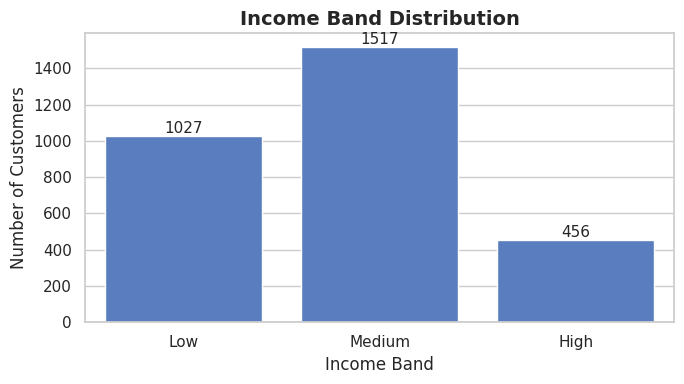

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
order = ['Low', 'Medium', 'High']
sns.countplot(data=df, x='Income Band', order=order, ax=ax)
ax.set_title('Income Band Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Income Band')
ax.set_ylabel('Number of Customers')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.savefig('visuals/income_band.png')
plt.show()

## 3. Univariate Analysis — Categorical Features

In [8]:
# Defined once and reused throughout
categorical_cols = [
    'BRId', 'GenderId', 'IAId', 'Amount of Credit Cards',
    'Nationality', 'Fee Structure', 'Loyalty Classification',
    'Properties Owned', 'Risk Weighting', 'Income Band'
]
# Note: 'Occupation' excluded from plots due to 195 unique categories

numerical_cols = [
    'Estimated Income', 'Superannuation Savings', 'Credit Card Balance',
    'Bank Loans', 'Bank Deposits', 'Checking Accounts',
    'Saving Accounts', 'Foreign Currency Account', 'Business Lending'
]

In [9]:
# Value counts for all categorical columns
for col in categorical_cols:
    print(f"Value Counts for '{col}':")
    display(df[col].value_counts())
    print()

Value Counts for 'BRId':


,count
BRId,
3,1352
1,660
2,495
4,493



Value Counts for 'GenderId':


,count
GenderId,
2,1512
1,1488



Value Counts for 'IAId':


...

,count
Properties Owned,
2,777
1,776
3,742
0,705



Value Counts for 'Risk Weighting':


,count
Risk Weighting,
2,1222
1,836
3,460
4,322
5,160



Value Counts for 'Income Band':


,count
Income Band,
Medium,1517
Low,1027
High,456


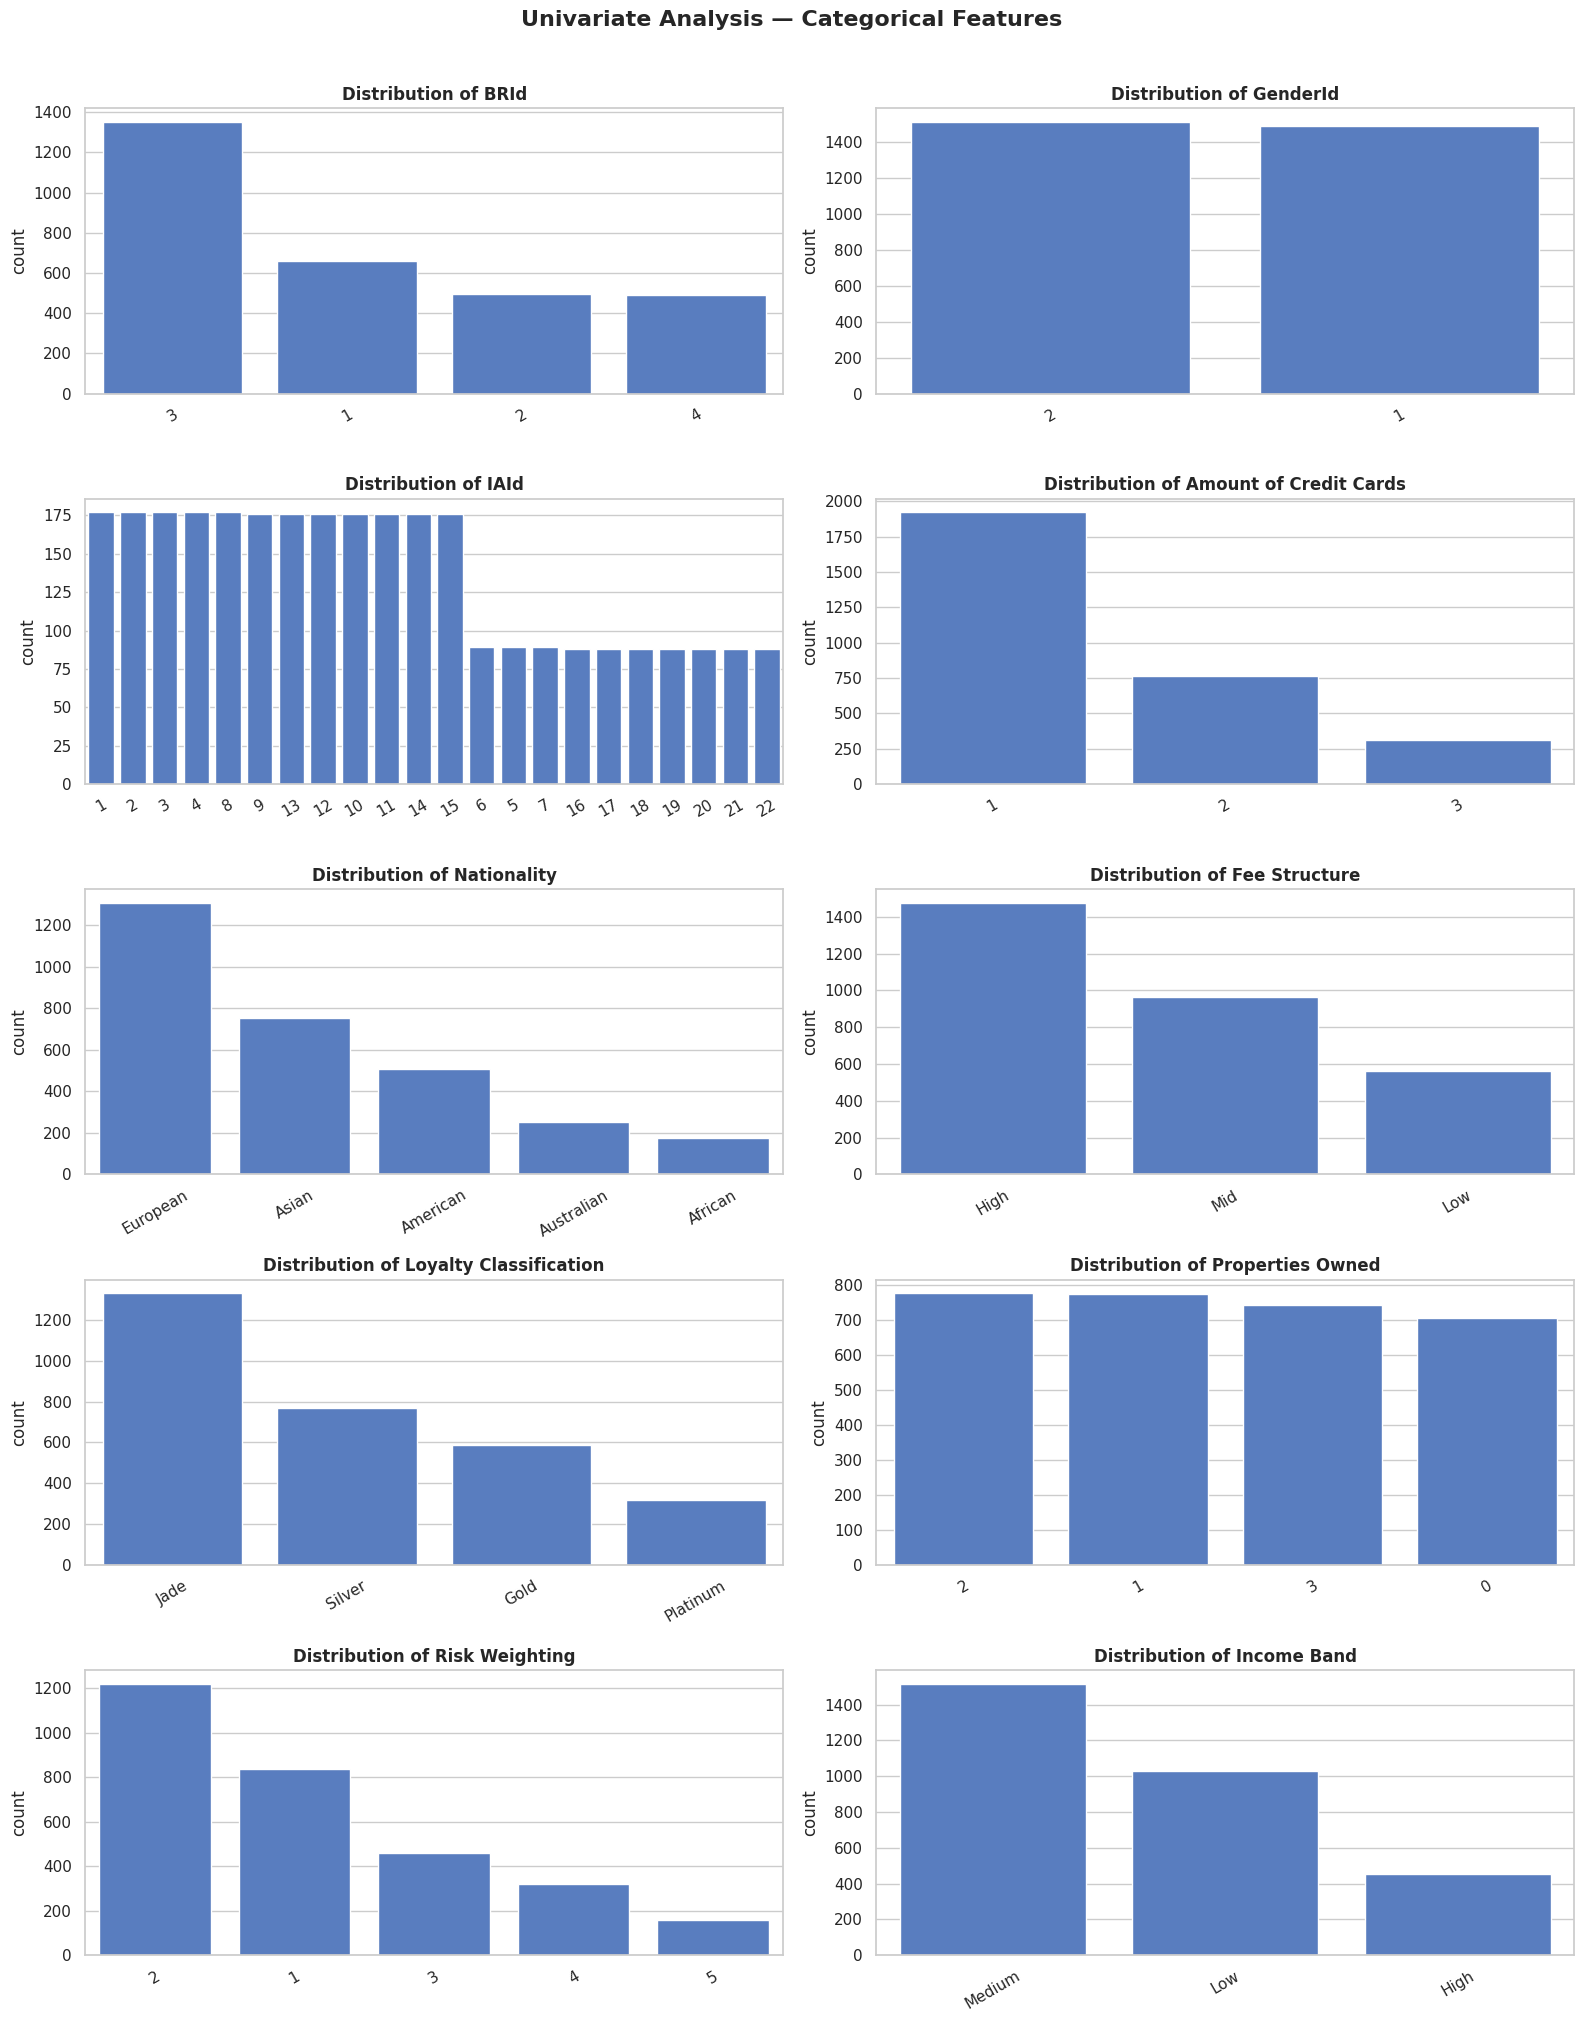

In [10]:
n_cols = 2
n_rows = (len(categorical_cols) + 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(data=df, x=col, ax=axes[i], order=df[col].value_counts().index)
    axes[i].set_title(f'Distribution of {col}', fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Univariate Analysis — Categorical Features', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('visuals/univariate_categorical.png', bbox_inches='tight')
plt.show()

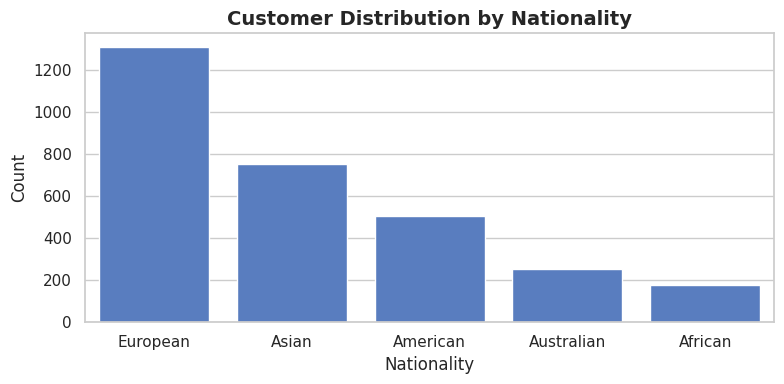

In [11]:
# Nationality breakdown only — save separately for README
fig, ax = plt.subplots(figsize=(8, 4))
sns.countplot(data=df, x='Nationality', order=df['Nationality'].value_counts().index, ax=ax)
ax.set_title('Customer Distribution by Nationality', fontsize=14, fontweight='bold')
ax.set_xlabel('Nationality')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('visuals/univariate_nationality.png')
plt.show()

## 4. Bivariate Analysis — Categorical Features × Nationality

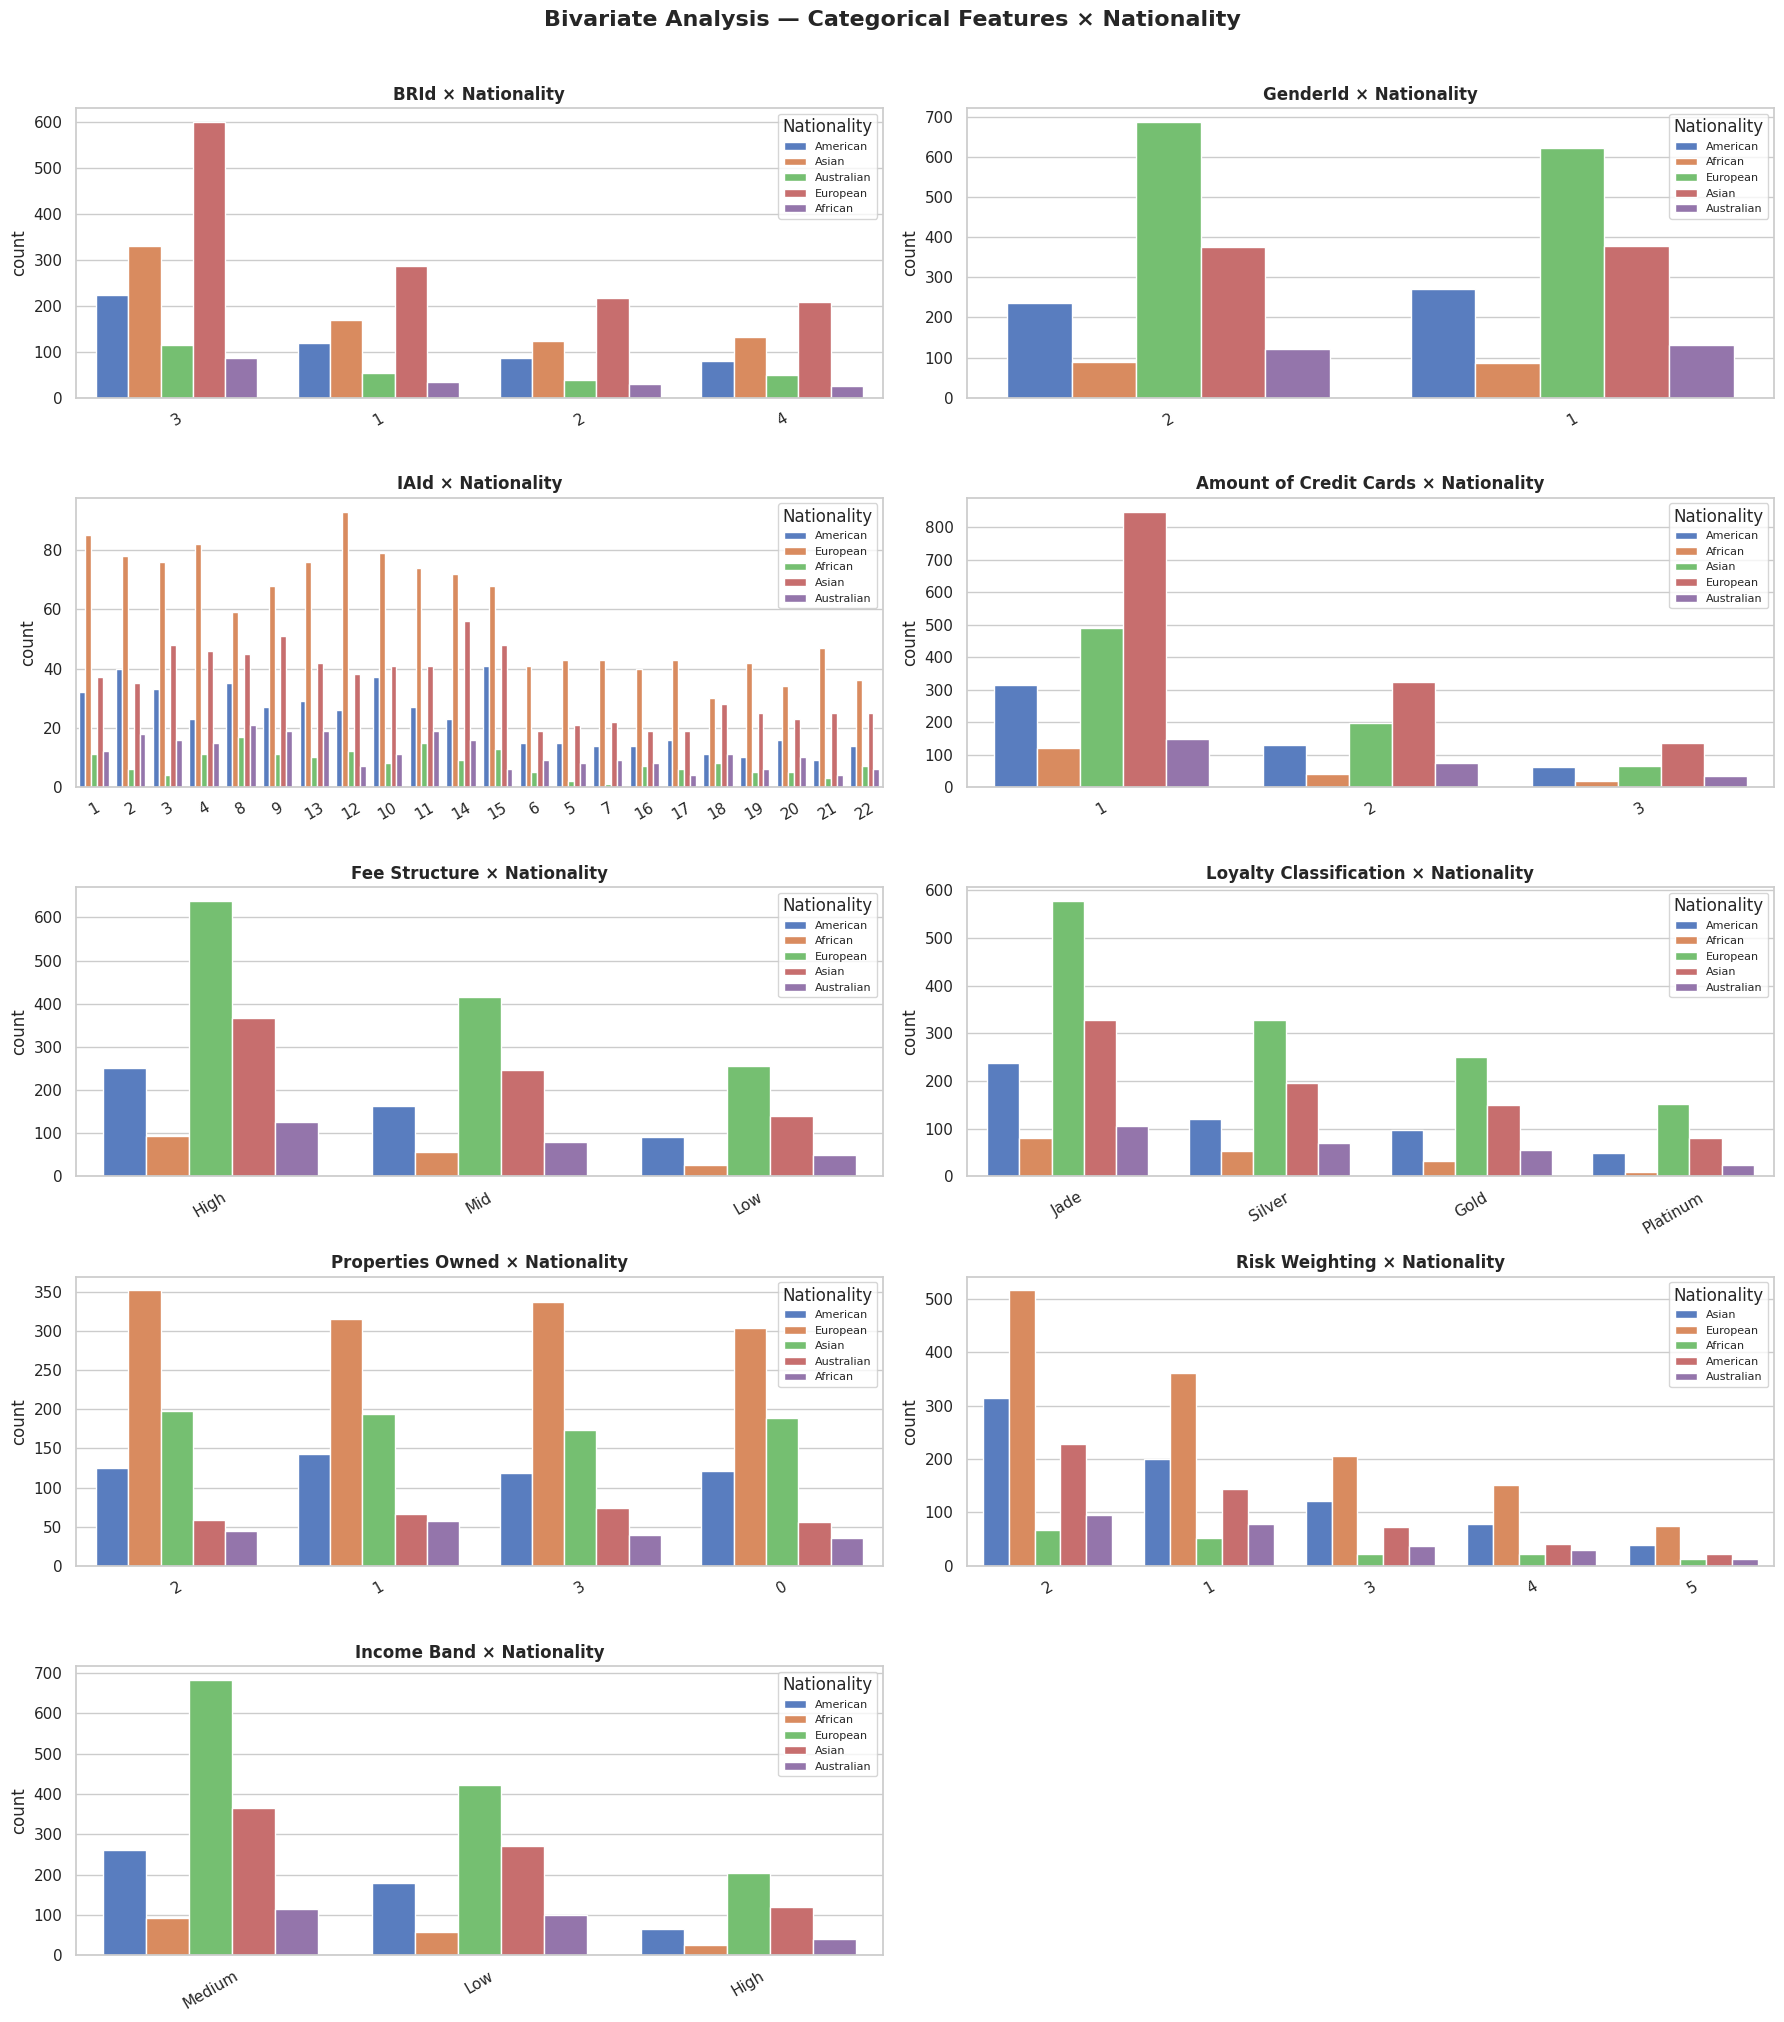

In [12]:
# Exclude 'Nationality' from bivariate since it's the hue variable
bivariate_cols = [col for col in categorical_cols if col != 'Nationality']

n_cols = 2
n_rows = (len(bivariate_cols) + 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(bivariate_cols):
    sns.countplot(data=df, x=col, hue='Nationality', ax=axes[i],
                  order=df[col].value_counts().index)
    axes[i].set_title(f'{col} × Nationality', fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(title='Nationality', fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Bivariate Analysis — Categorical Features × Nationality', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('visuals/bivariate_categorical_nationality.png', bbox_inches='tight')
plt.show()

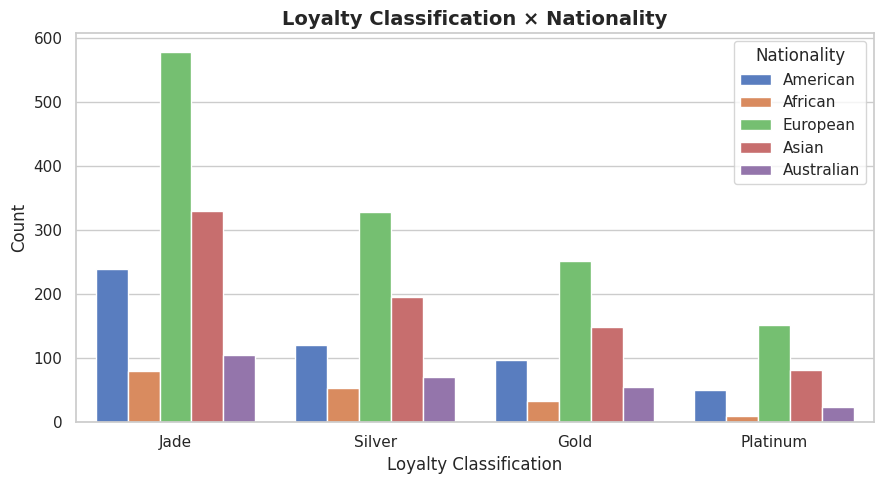

In [13]:
# Loyalty × Nationality — save separately for README
fig, ax = plt.subplots(figsize=(9, 5))
sns.countplot(data=df, x='Loyalty Classification', hue='Nationality',
              order=df['Loyalty Classification'].value_counts().index, ax=ax)
ax.set_title('Loyalty Classification × Nationality', fontsize=14, fontweight='bold')
ax.set_xlabel('Loyalty Classification')
ax.set_ylabel('Count')
ax.legend(title='Nationality')
plt.tight_layout()
plt.savefig('visuals/bivariate_loyalty_nationality.png')
plt.show()

## 5. Numerical Analysis — Distributions

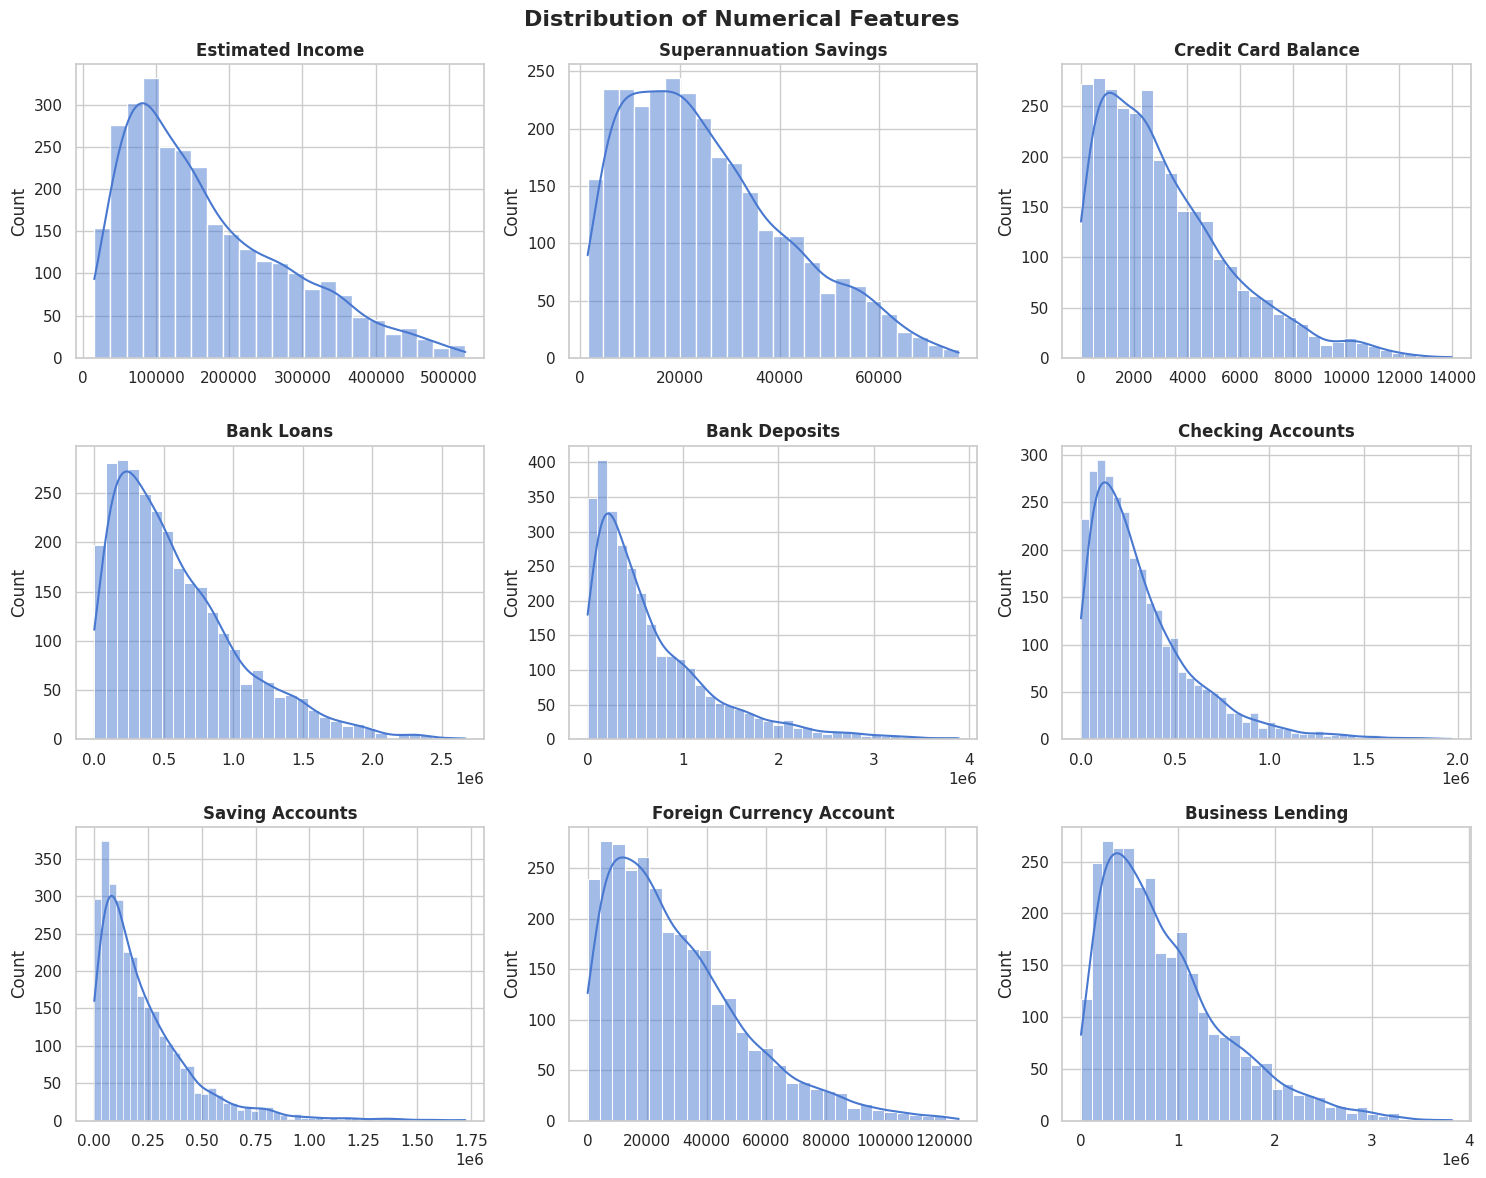

In [14]:
plt.figure(figsize=(15, 12))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(col, fontweight='bold')
    plt.xlabel('')
plt.suptitle('Distribution of Numerical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('visuals/numerical_histograms.png')
plt.show()

## 6. Bivariate Analysis — Income Band × Numerical Features

In [15]:
# Average financial metrics per income band
income_band_summary = df.groupby('Income Band', observed=True)[numerical_cols].mean().round(0)
print('Average financial metrics by Income Band:')
display(income_band_summary)

Average financial metrics by Income Band:


,Estimated Income,Superannuation Savings,Credit Card Balance,Bank Loans,Bank Deposits,Checking Accounts,Saving Accounts,Foreign Currency Account,Business Lending
Income Band,,,,,,,,,
Low,64689.0,18793.0,2349.0,436410.0,486223.0,231433.0,170391.0,22696.0,636062.0
Medium,182132.0,27291.0,3345.0,621286.0,719400.0,341785.0,246008.0,30815.0,913226.0
High,375405.0,34854.0,4478.0,840951.0,929822.0,454186.0,330129.0,42973.0,1231755.0


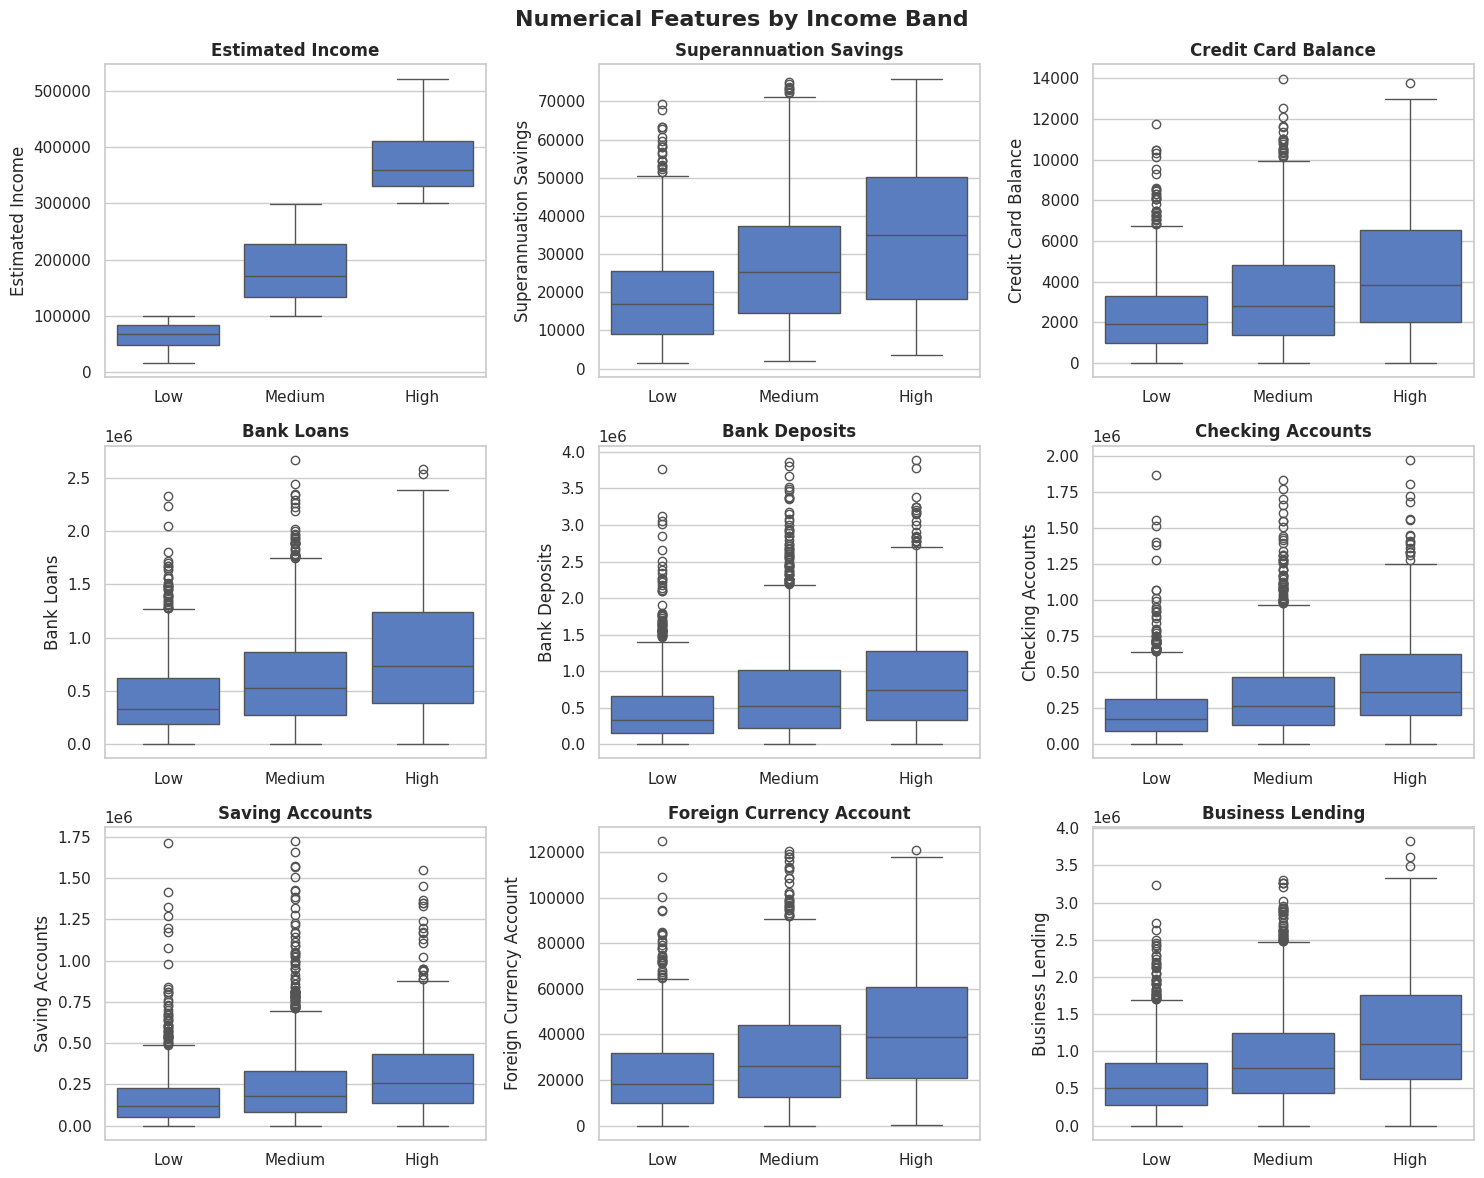

In [16]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(data=df, x='Income Band', y=col, order=['Low', 'Medium', 'High'], ax=axes[i])
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('')

plt.suptitle('Numerical Features by Income Band', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('visuals/boxplot_income_band.png')
plt.show()

## 7. Correlation Matrix

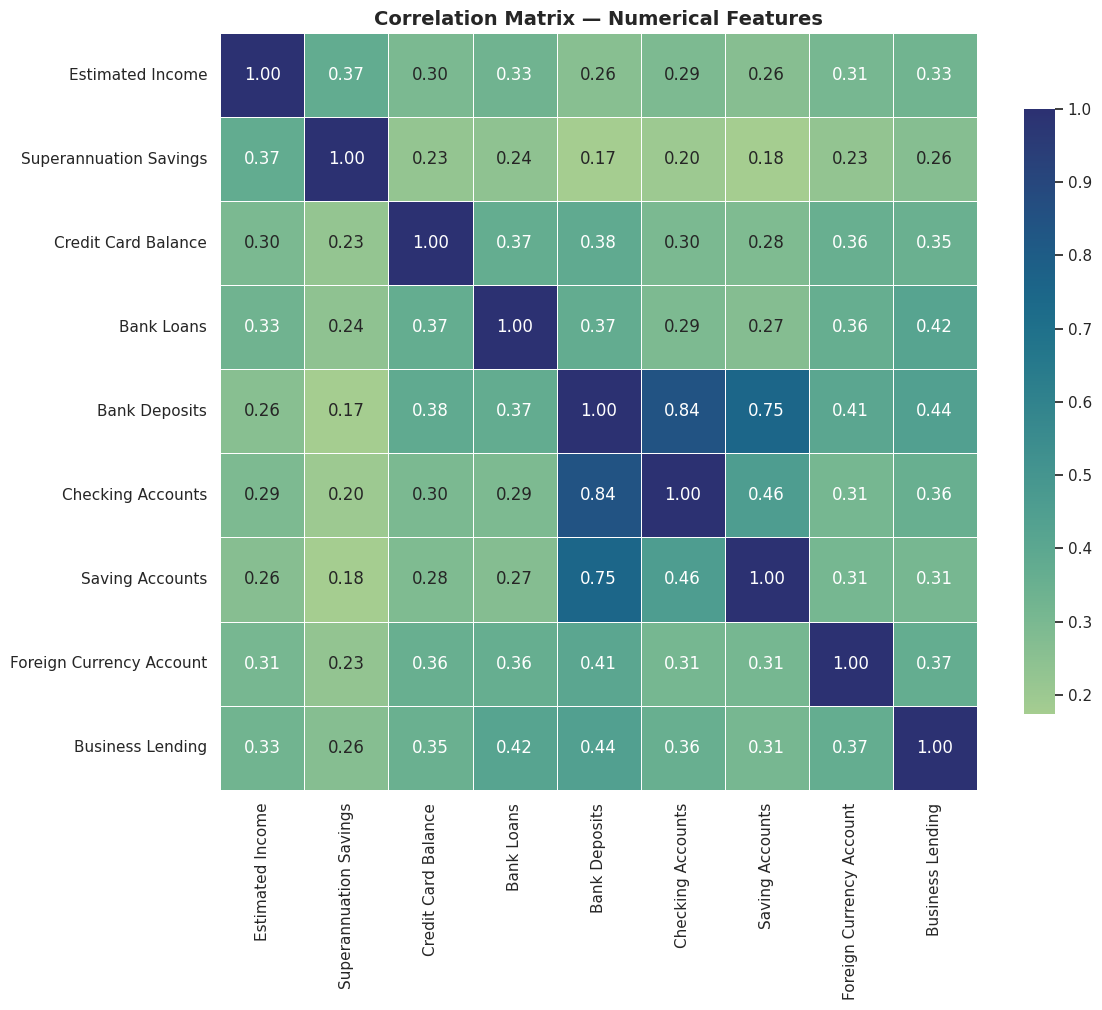

In [17]:
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='crest',
    fmt='.2f',
    linewidths=0.5,
    square=True,
    cbar_kws={'shrink': 0.8}
)
plt.title('Correlation Matrix — Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('visuals/correlation_heatmap.png')
plt.show()

In [18]:
# Top correlated pairs (excluding self-correlations)
corr_pairs = (
    correlation_matrix
    .where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)
corr_pairs.columns = ['Feature 1', 'Feature 2', 'Correlation']
corr_pairs = corr_pairs.reindex(corr_pairs['Correlation'].abs().sort_values(ascending=False).index)
print('Top 10 correlated feature pairs:')
display(corr_pairs.head(10))

Top 10 correlated feature pairs:


,Feature 1,Feature 2,Correlation
26,Bank Deposits,Checking Accounts,0.844278
27,Bank Deposits,Saving Accounts,0.754744
30,Checking Accounts,Saving Accounts,0.459509
29,Bank Deposits,Business Lending,0.441298
25,Bank Loans,Business Lending,0.417095
28,Bank Deposits,Foreign Currency Account,0.406347
16,Credit Card Balance,Bank Deposits,0.383877
0,Estimated Income,Superannuation Savings,0.374802
21,Bank Loans,Bank Deposits,0.373155
35,Foreign Currency Account,Business Lending,0.369749


## 8. Key Insights

1. **Bank Deposits is highly correlated with Checking, Saving, and Foreign Currency accounts:** customers with high deposit balances tend to hold substantial funds across all account types, pointing to a wealth concentration effect. These clients represent lower lending risk.

2. **Income distribution is dominated by the Medium band (51%):** over half the customer base earns between $100k and $300k. This segment requires careful risk calibration as they are neither clearly low-risk nor high-risk borrowers.

3. **Risk Weighting is skewed toward low risk:** 70%+ of customers sit at Risk Weighting 1 or 2, but the tail (levels 4–5) represents ~160 high-risk profiles that warrant dedicated monitoring to minimise potential losses.

4. **Credit Card Balance shows weak correlation with Income:** credit usage appears driven more by spending behavior than earning capacity, reinforcing the need for behavioral data in credit risk models rather than income alone.

5. **Loyalty tier Jade dominates (44%):** combined with the prevalence of the High fee structure (49%), this suggests a customer base that is both loyal and financially engaged, reducing the probability of sudden default or churn.